### Лабораторная работа № 2

In [1]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

#### Загрузка данных

In [2]:
# Загрузка данных из Excel файла
df = pd.read_excel('Real estate valuation data set.xlsx')
df.head(5)

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,Возраст дома,Кол-во магазинов,Расстояние до ближайшей станции метро
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9,старый,много,среднее
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2,старый,много,среднее
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3,средний возраст,среднее,среднее
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8,средний возраст,среднее,среднее
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1,средний возраст,среднее,среднее


#### Анализ данных


In [3]:
# размер датасета, 414 записей, 11 столбцов

df.shape

(414, 11)

In [4]:
# отображаем первые 10 строк датасета

df.head(10)

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,Возраст дома,Кол-во магазинов,Расстояние до ближайшей станции метро
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9,старый,много,среднее
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2,старый,много,среднее
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3,средний возраст,среднее,среднее
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8,средний возраст,среднее,среднее
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1,средний возраст,среднее,среднее
5,6,2012.666667,7.1,2175.03000,3,24.96305,121.51254,32.1,средний возраст,мало,далеко
6,7,2012.666667,34.5,623.47310,7,24.97933,121.53642,40.3,старый,много,среднее
7,8,2013.416667,20.3,287.60250,6,24.98042,121.54228,46.7,старый,среднее,среднее
8,9,2013.500000,31.7,5512.03800,1,24.95095,121.48458,18.8,старый,мало,далеко
9,10,2013.416667,17.9,1783.18000,3,24.96731,121.51486,22.1,старый,мало,далеко


In [5]:
import mpl_toolkits.mplot3d  # noqa: F401


from sklearn import datasets
from sklearn.cluster import KMeans

In [6]:
# Метод Pandas info()  выводит очень много информации о наборе данных - количество записей,
# количество ненулевых значений в каждом столбце, тип данных в столбце

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 11 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
 8   Возраст дома                            414 non-null    object 
 9   Кол-во магазинов                        414 non-null    object 
 10  Расстояние до ближайшей станции метро   414 non-null    object

In [7]:
df = df.drop('No', axis=1)

In [8]:
# Pandas describe() используется для просмотра  основной статистической информации, таких как процентиль, среднее,
# стандартное отклонение и т.д. фрейма данных или ряда числовых значений:

df.describe()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [9]:
df['Возраст дома'].unique()

array(['старый', 'средний возраст', 'новостройка'], dtype=object)

In [10]:
df['Кол-во магазинов'].unique()

array(['много', 'среднее', 'мало'], dtype=object)

In [11]:
df['Расстояние до ближайшей станции метро'].unique()

array(['среднее', 'далеко', 'близко'], dtype=object)

In [12]:
# Теперь проверим количество строк, которое принадлежит каждой Возрасту дома:

df['Возраст дома'].value_counts()

,count
Возраст дома,
старый,180
средний возраст,171
новостройка,63


In [13]:
# Теперь проверим количество строк, которое принадлежит каждой Кол-ву магазинов:

df['Кол-во магазинов'].value_counts()

,count
Кол-во магазинов,
мало,183
среднее,135
много,96


In [14]:
# Теперь проверим количество строк, которое принадлежит каждой Расстояние до ближайшей станции метро:

df['Расстояние до ближайшей станции метро'].value_counts()

,count
Расстояние до ближайшей станции метро,
среднее,278
далеко,134
близко,2


In [15]:
df['Расстояние до ближайшей станции метро'].describe()

,Расстояние до ближайшей станции метро
count,414
unique,3
top,среднее
freq,278


#### Визуализация данных

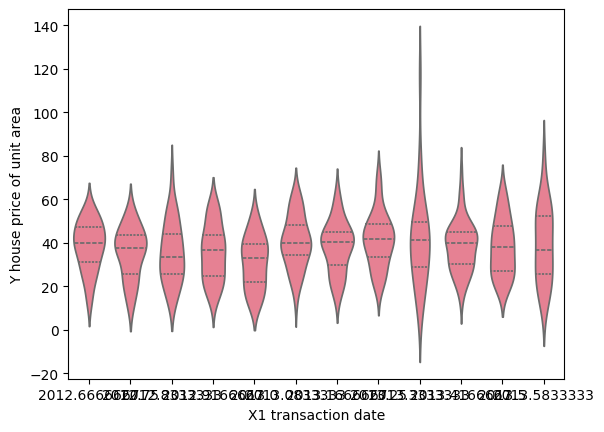

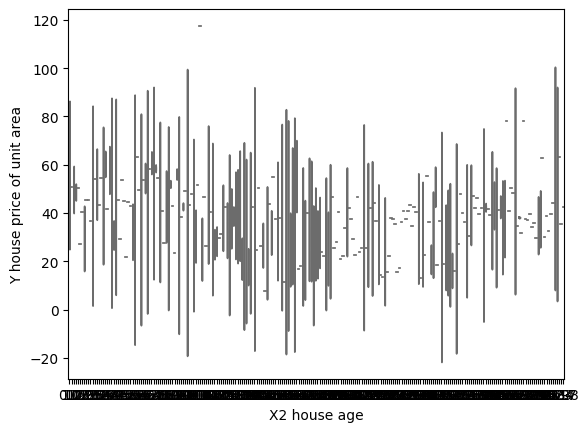

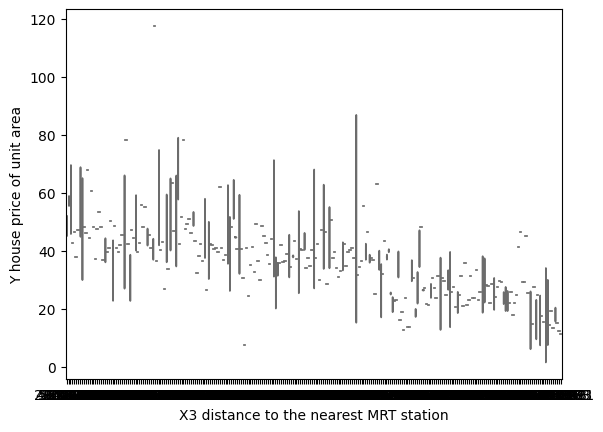

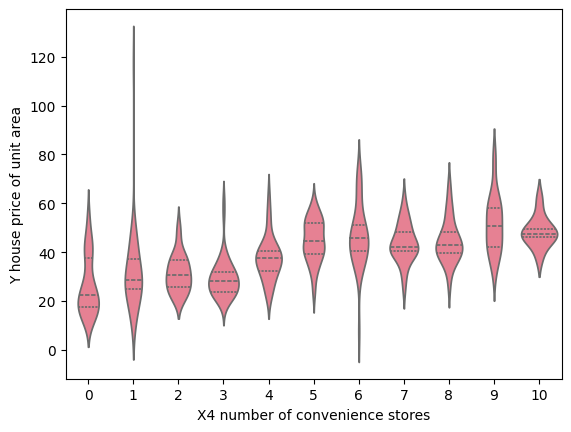

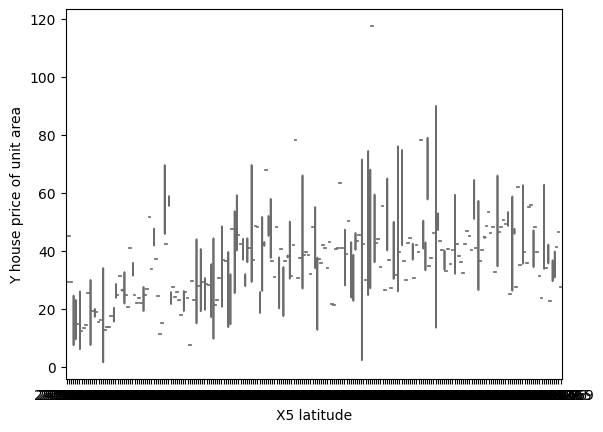

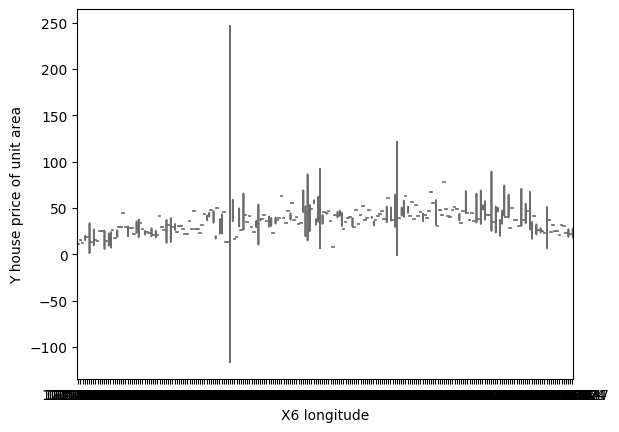

In [16]:
# Скрипичный график.
# Используется для проверки сравнения распределения переменных:

sns.violinplot(y='Y house price of unit area', x='X1 transaction date', data=df, inner='quartile')
plt.show()
sns.violinplot(y='Y house price of unit area', x='X2 house age', data=df, inner='quartile')
plt.show()
sns.violinplot(y='Y house price of unit area', x='X3 distance to the nearest MRT station', data=df, inner='quartile')
plt.show()
sns.violinplot(y='Y house price of unit area', x='X4 number of convenience stores', data=df, inner='quartile')
plt.show()
sns.violinplot(y='Y house price of unit area', x='X5 latitude', data=df, inner='quartile')
plt.show()
sns.violinplot(y='Y house price of unit area', x='X6 longitude', data=df, inner='quartile')
plt.show()

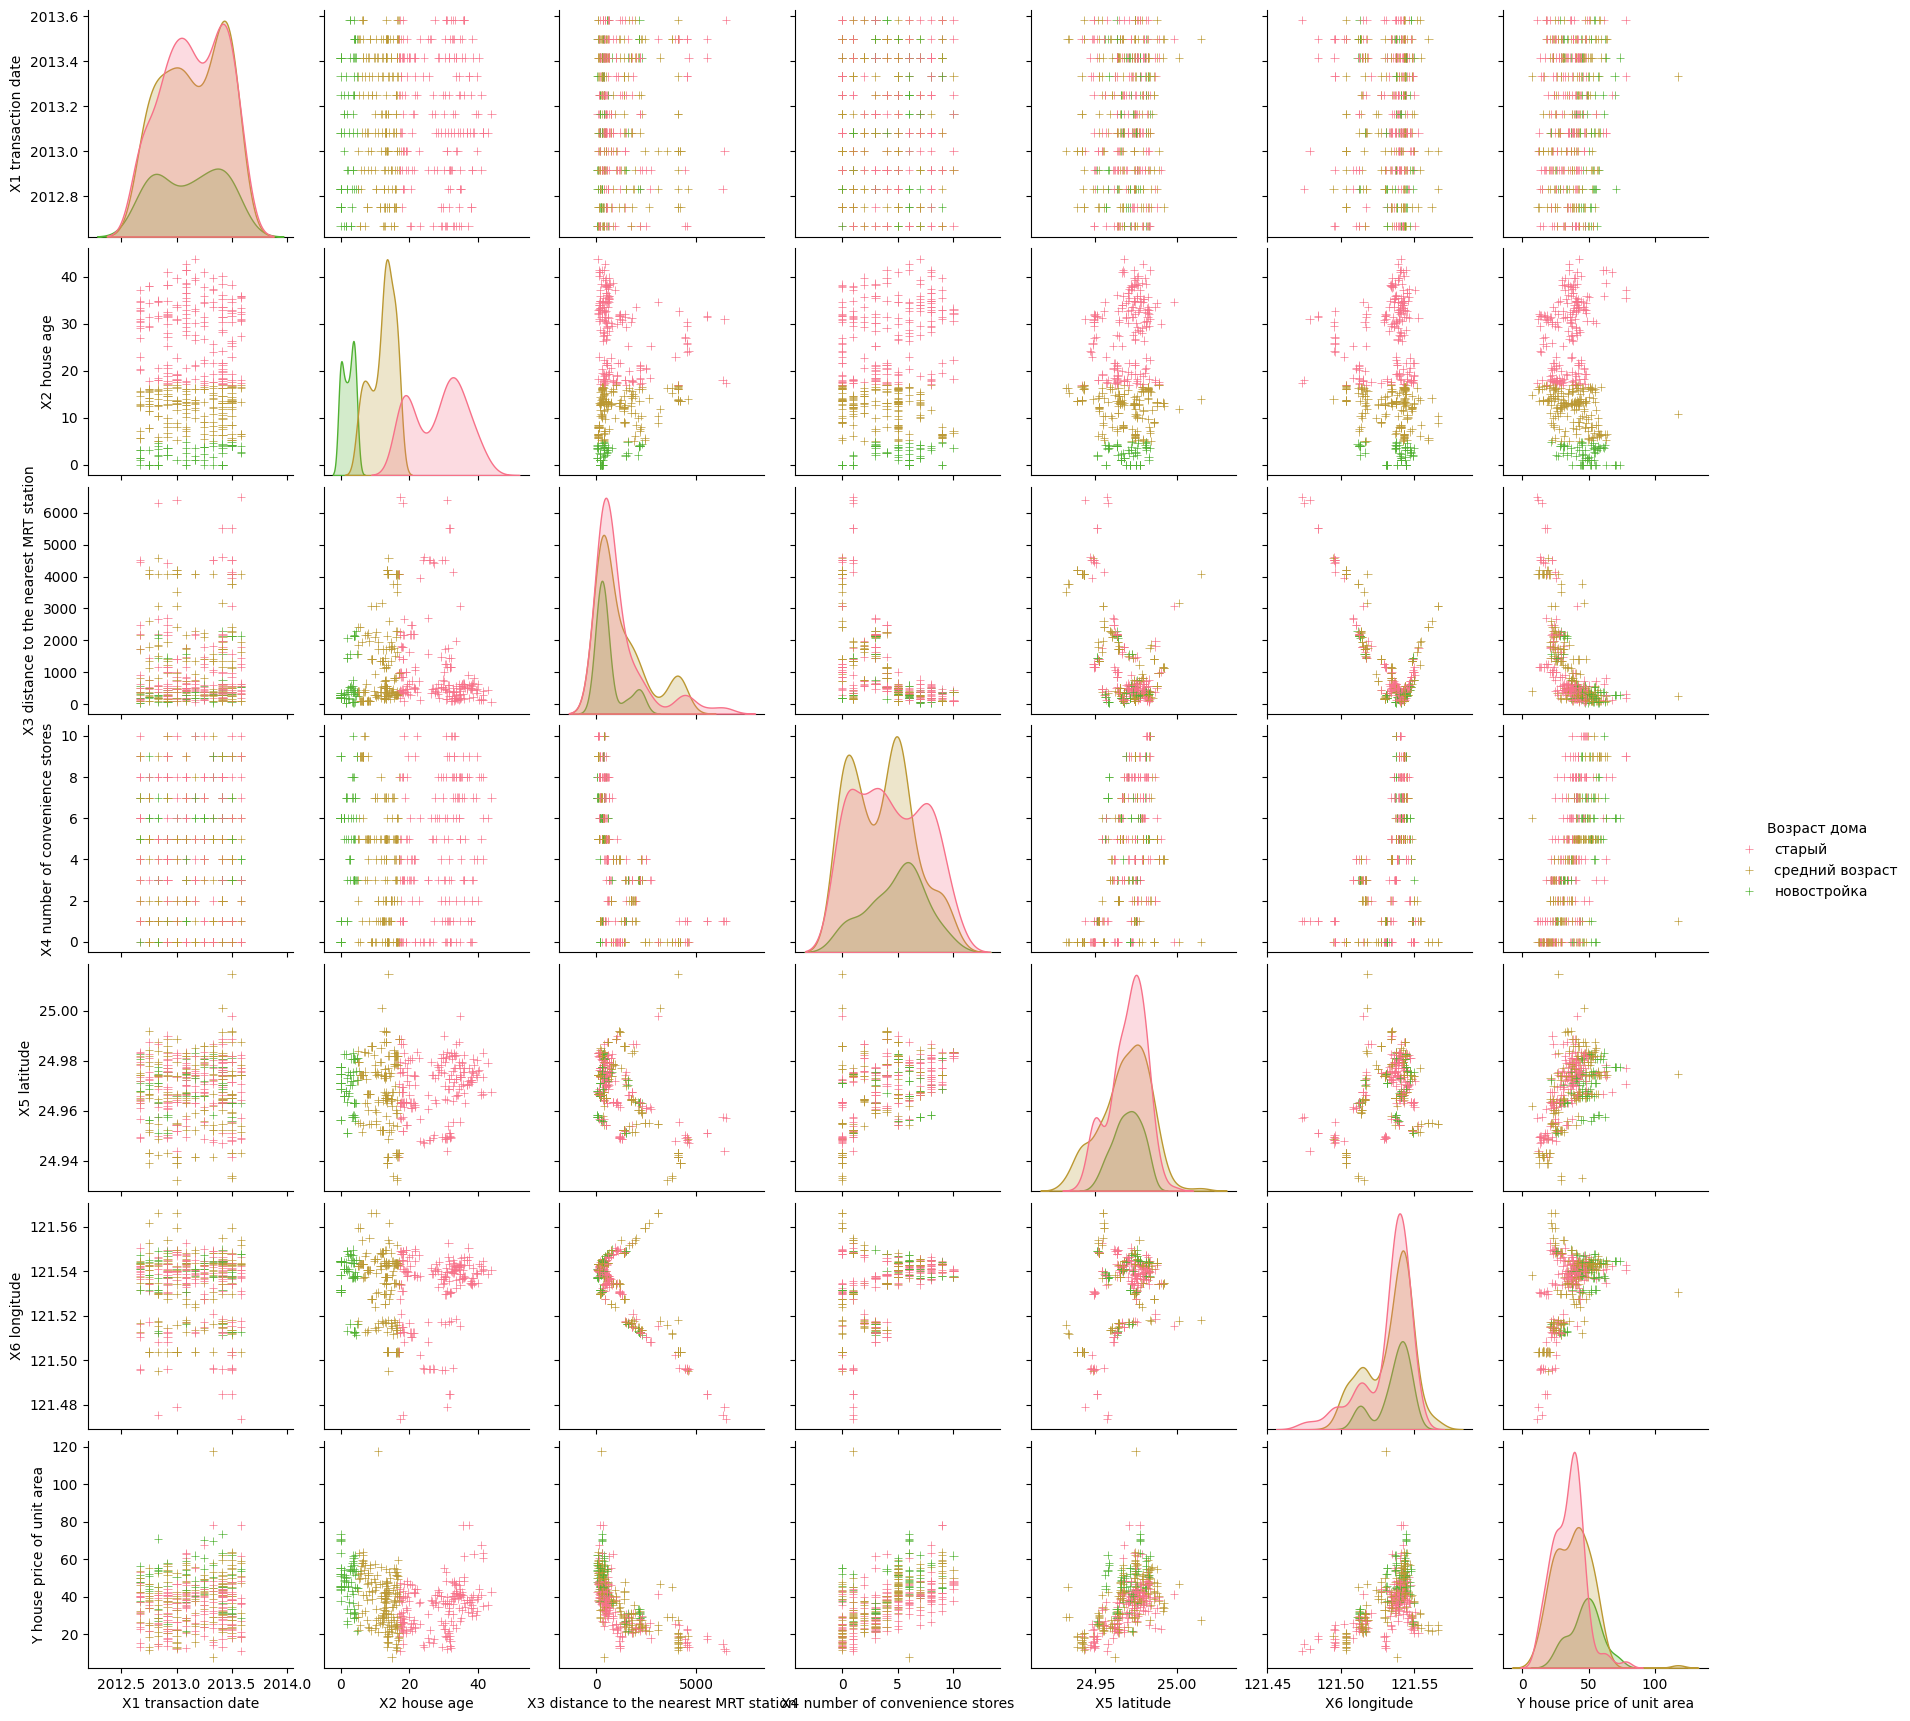

In [17]:
# Парный график
#Построение нескольких попарных двумерных распределений в наборе данных с помощью pairplot:

sns.pairplot(df, hue='Возраст дома', markers='+')
plt.show()

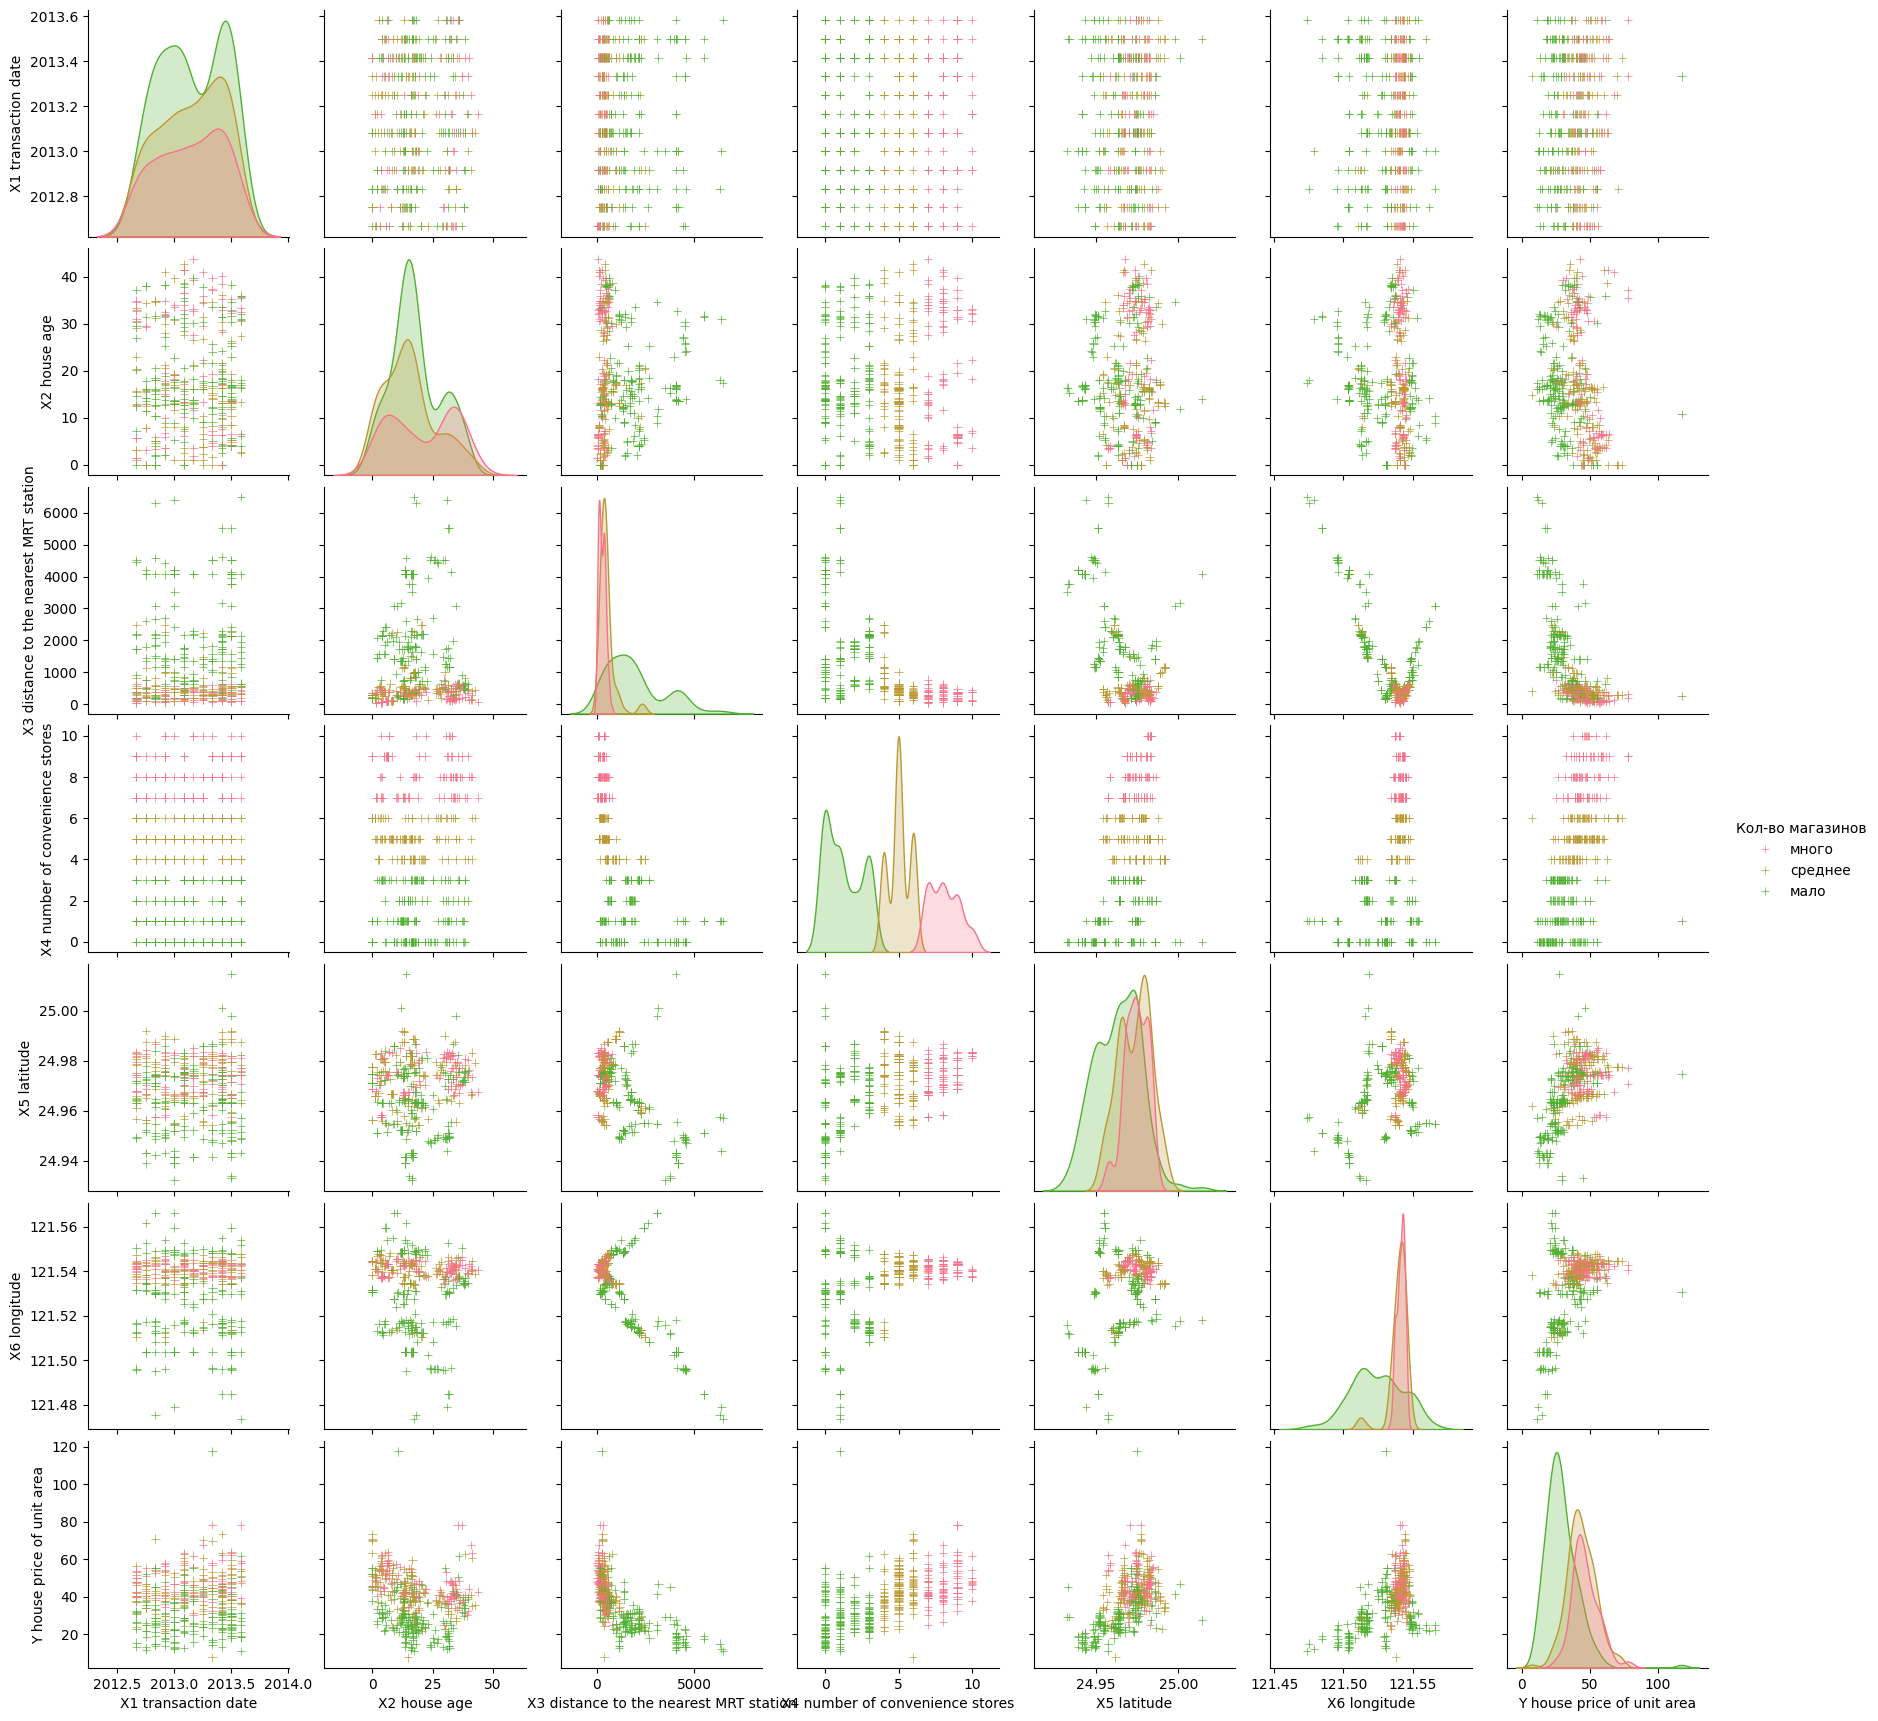

In [18]:
# Парный график
#Построение нескольких попарных двумерных распределений в наборе данных с помощью pairplot:

sns.pairplot(df, hue='Кол-во магазинов', markers='+')
plt.show()

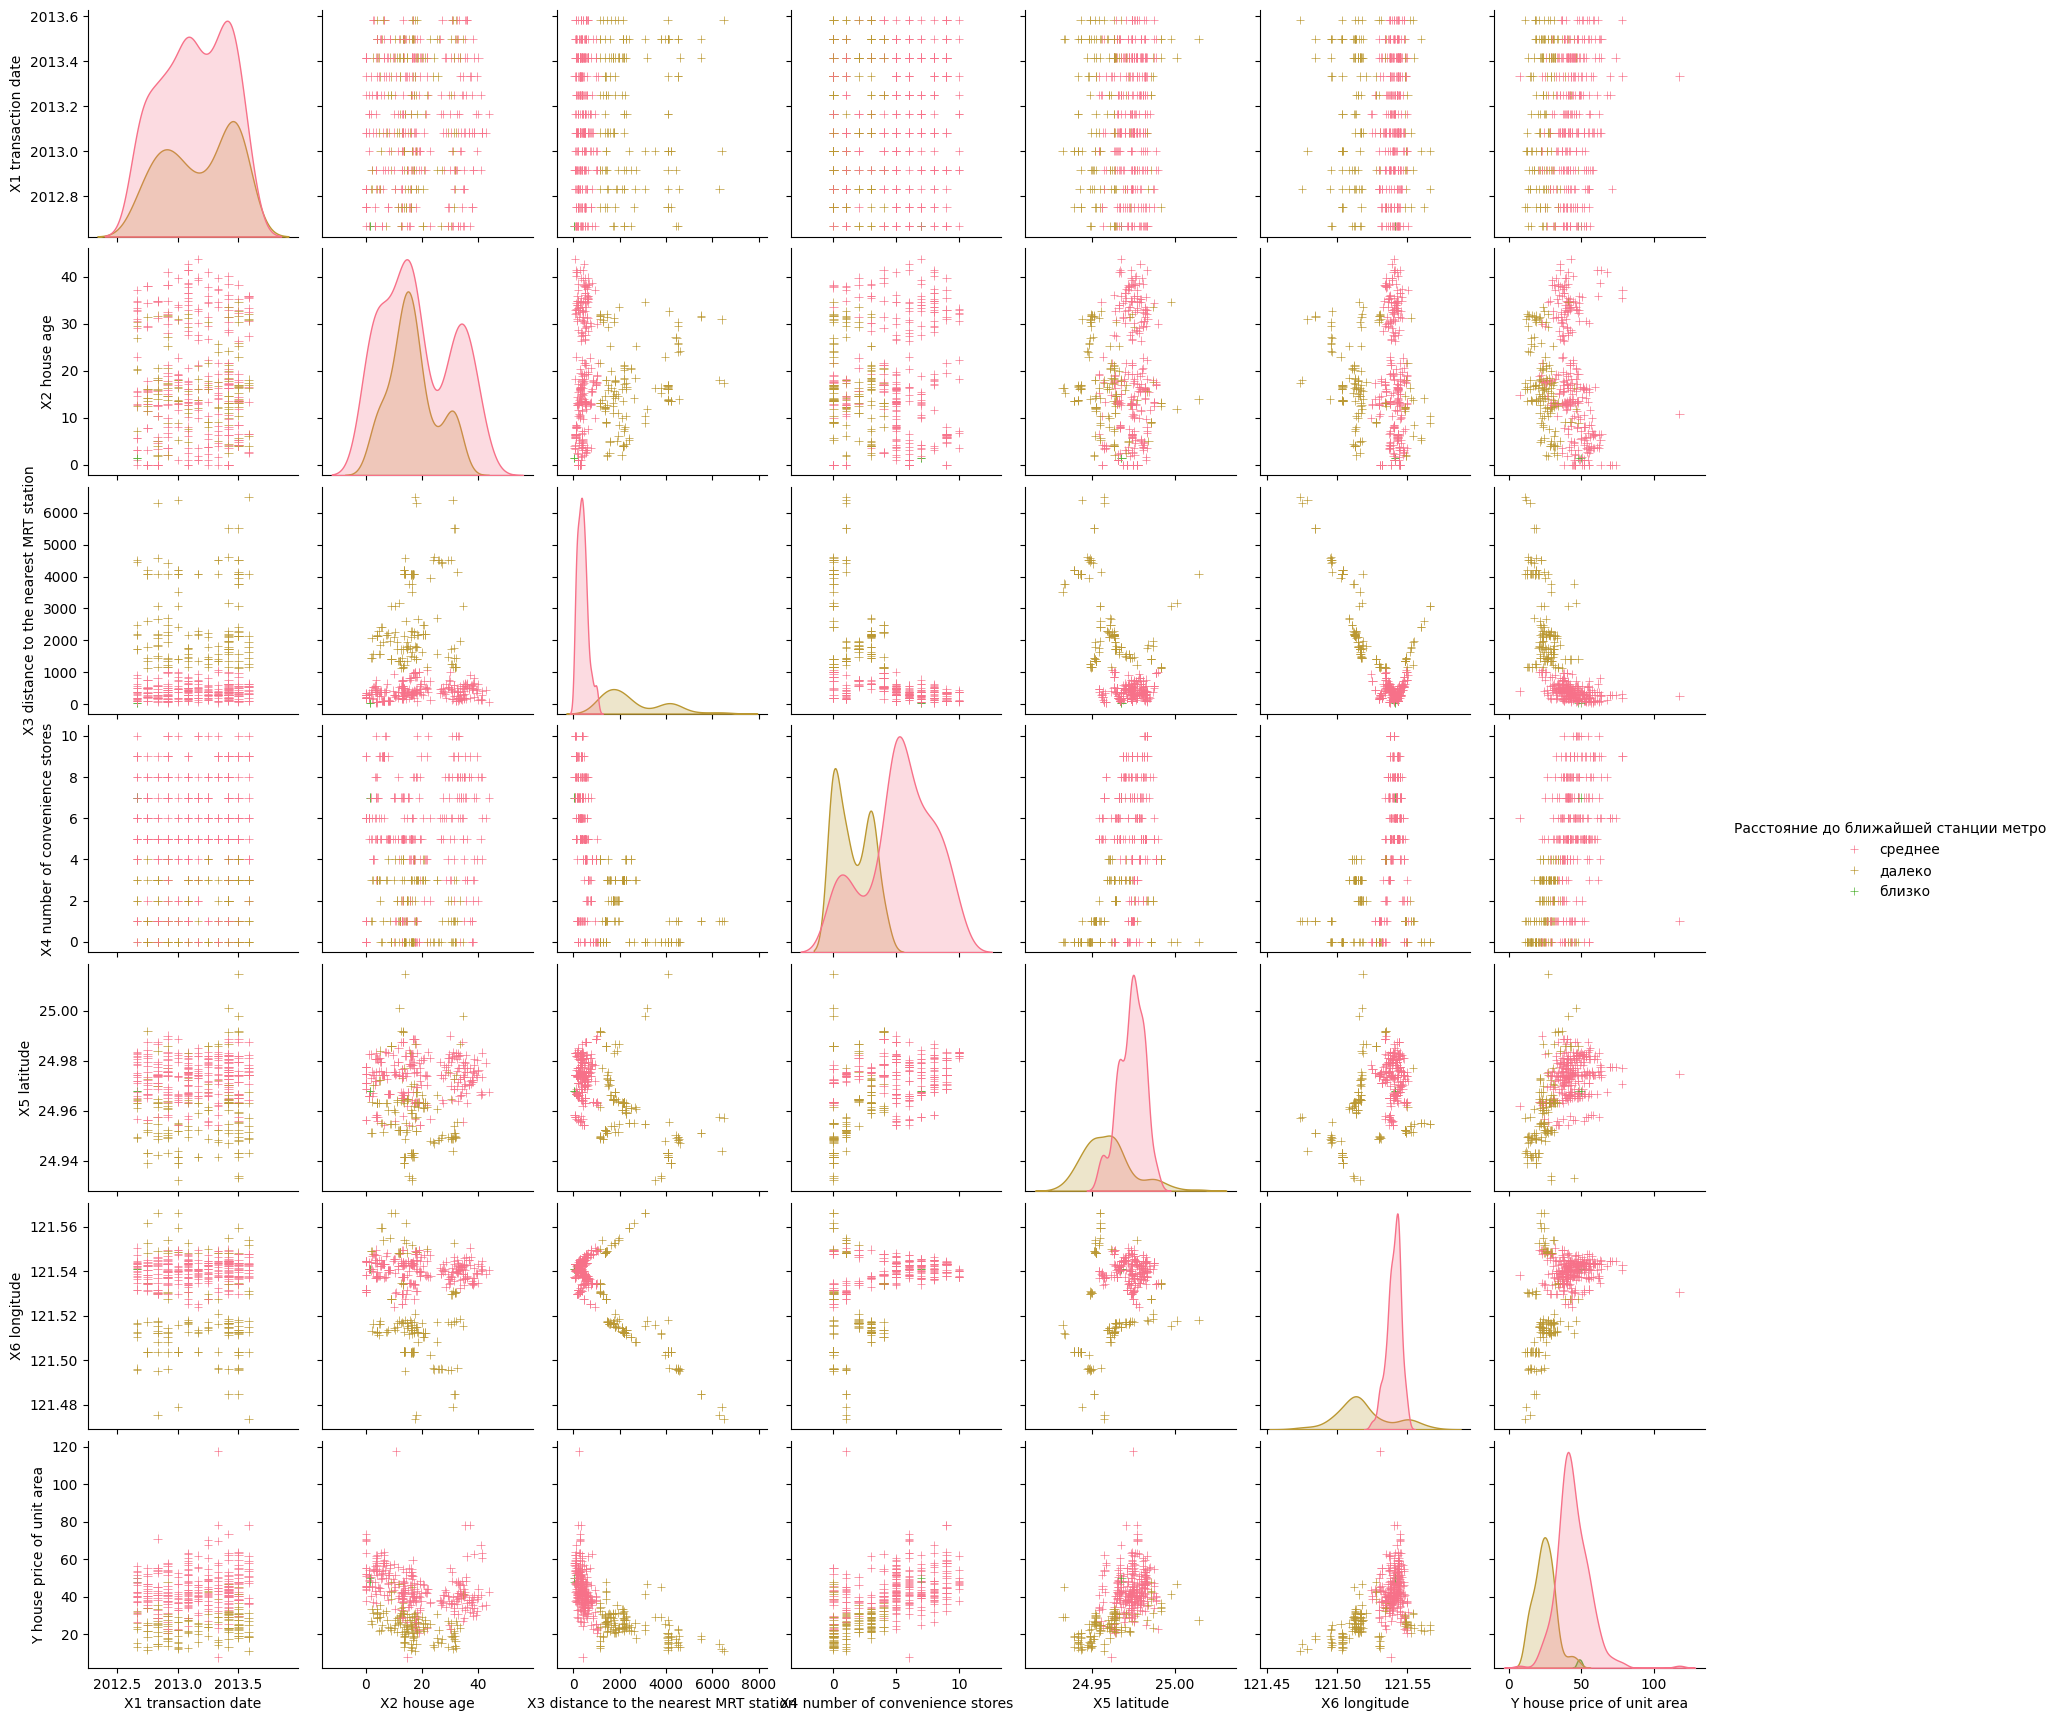

In [19]:
# Парный график
#Построение нескольких попарных двумерных распределений в наборе данных с помощью pairplot:

sns.pairplot(df, hue='Расстояние до ближайшей станции метро', markers='+')
plt.show()

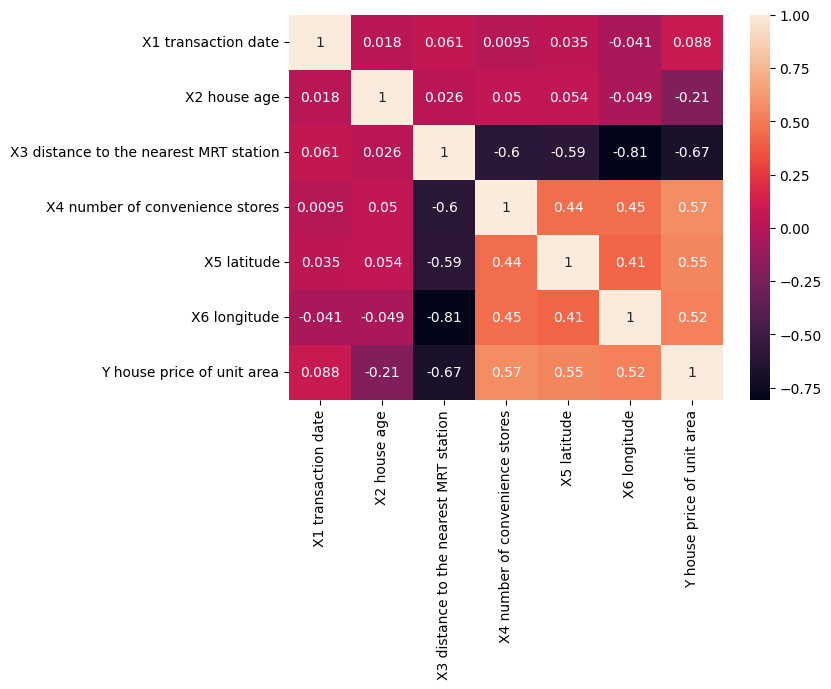

In [20]:
# Тепловая карта
# Построение тепловой карты для проверки корреляции.
# dataset.corr() используется для поиска попарной корреляции всех столбцов в кадре данных.

plt.figure(figsize=(7,5))
sns.heatmap(df.corr(numeric_only = True), annot=True)
plt.show()

#### Построение модели

Разделение набора данных
Y - целевая переменная, которую предсказываем. Мы ищем зависимость этой переменной от соответствующих фич.

В X складываем весь набор данных без целевой переменной.

In [31]:
from sklearn.preprocessing import OrdinalEncoder
y_mapped = OrdinalEncoder()
df[['Возраст дома', 'Кол-во магазинов', 'Расстояние до ближайшей станции метро']] = y_mapped.fit_transform(df[['Возраст дома', 'Кол-во магазинов', 'Расстояние до ближайшей станции метро']])
df.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,Возраст дома,Кол-во магазинов,Расстояние до ближайшей станции метро
0,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9,2.0,1.0,2.0
1,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2,2.0,1.0,2.0
2,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3,1.0,2.0,2.0
3,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8,1.0,2.0,2.0
4,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1,1.0,2.0,2.0


In [36]:
#Преобразуем признаки (X), а не целевую переменную (y)
features = ['Возраст дома', 'Кол-во магазинов', 'Расстояние до ближайшей станции метро']
df[features] = y_mapped.fit_transform(df[features])

In [37]:
X = df.drop(['Возраст дома'], axis=1)
y = df['Возраст дома']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (414, 9) | y shape: (414,) 


X имеет 414 строк и 10 столбцов, тогда как Y имеет 414 строк и только один столбец.

#### Train Test разделение

Разделяем наш набор данных на обучающий (train) и тестовый (test) с помощью train_test_split(), мы берем 80% данных для обучения нашей модели и 20% оставляем в качестве проверочного набора данных:

**Рассмотрим столбец Возраст дома:**

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=10)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=15
    # stratify убираем для регрессии!
)
stats.ttest_ind (a=y_train, b=y_test)

TtestResult(statistic=np.float64(0.07850878336699699), pvalue=np.float64(0.9374614589054533), df=np.float64(412.0))

#### Обучение и выбор оптимальной модели

Далее попробуем следующие алгоритмы:

Logistic Regression (LR) </br>
Linear Discriminant Analysis (LDA)</br>
K-Nearest Neighbors (KNN)</br>
Classification and Regression Trees (CART)</br>
Gaussian Naive Bayes (NB)</br>
Support Vector Machines (SVM)</br>

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

In [45]:
# создаем лист для тех моделей, которые будем изучать
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVC', SVC(gamma='auto')))

# оцениваем их метрики
results = []
model_names = []
for name, model in models:
  kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
  cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
  results.append(cv_results)
  model_names.append(name)
  print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

LR: 0.984848 (0.020328)
LDA: 0.830927 (0.046810)
KNN: 0.700624 (0.074309)
CART: 1.000000 (0.000000)
NB: 0.897326 (0.047210)
SVC: 0.683066 (0.087706)


LinearDiscriminantAnalysis и Наивный Байесовский классификатор показали лучшие метрики среди всех алгоритмов.
Далее работаем с LinearDiscriminantAnalysis.

Давайте обучим модель LDA на нашем обучающем наборе и сделаем прогноз на тестовом наборе на следующем шаге.

#### Обучение конкретной модели
Определяем нашу модель LDA
После этого подгоняем/обучаем модель на X_train и Y_train с помощью метода .fit().
Затем мы делаем прогноз на X_test с помощью метода .predict().

In [46]:
sk_lda = LinearDiscriminantAnalysis(solver='eigen')
sk_lda.fit(X_train, y_train)
sk_lda_pred_res = sk_lda.predict(X_test)
sk_transformed = sk_lda.transform(X_train)
sk_lda_accuracy = accuracy_score(y_test, sk_lda_pred_res)

print(f'sk LDA accuracy: {sk_lda_accuracy}')
print(f'sk LDA prediction: {sk_lda_pred_res}')
print('sk transformed features', sk_transformed[:5].T, sep='\n')

sk LDA accuracy: 0.8313253012048193
sk LDA prediction: [1. 1. 2. 1. 0. 2. 1. 1. 2. 2. 1. 1. 0. 2. 2. 0. 2. 0. 2. 1. 1. 1. 1. 1.
 2. 2. 1. 1. 1. 0. 2. 1. 1. 1. 2. 1. 1. 1. 2. 1. 1. 2. 1. 2. 1. 0. 2. 2.
 2. 2. 1. 2. 1. 1. 2. 1. 2. 1. 1. 1. 2. 1. 1. 0. 1. 1. 1. 1. 2. 0. 2. 2.
 1. 1. 1. 1. 1. 0. 1. 1. 2. 1. 2.]
sk transformed features
[[-1322.40268876 -1323.45747608 -1326.28426411 -1322.4764002
  -1321.27125837]
 [-9369.63203231 -9370.37347405 -9368.98789274 -9369.68392996
  -9369.45846481]]


#### Визуализация решения

In [47]:
df.columns

Index(['X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area', 'Возраст дома', 'Кол-во магазинов',
       'Расстояние до ближайшей станции метро'],
      dtype='object')

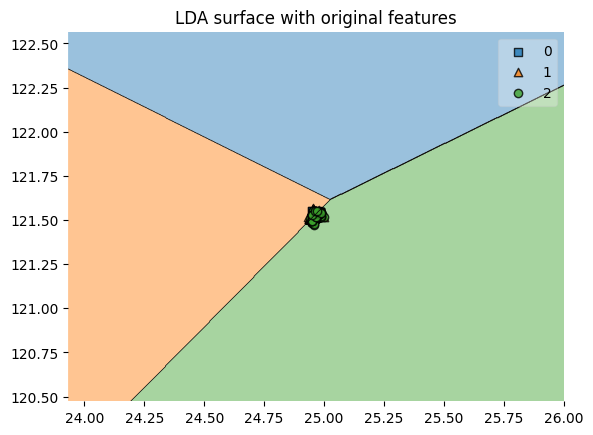

In [49]:
from mlxtend.plotting import plot_decision_regions
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import numpy as np

# Создадим целевой вектор
y_s = y_train  # Возраст дома
X_2d = X_train[['X5 latitude', 'X6 longitude']].values
# Преобразуем y в целые числа (классы)
y_2d = y_s.values.astype(np.int_)

# Создаём и обучаем модель
sk_lda1 = LinearDiscriminantAnalysis(solver='eigen')
sk_lda1.fit(X_2d, y_2d)
# Построение графика
plt.title('LDA surface with original features')
plot_decision_regions(
    X=X_2d,
    y=y_2d,
    clf=sk_lda1
)
plt.show()

LinearDiscriminantAnalysis(solver='eigen')


<Axes: title={'center': 'LDA surface with transformed features'}>

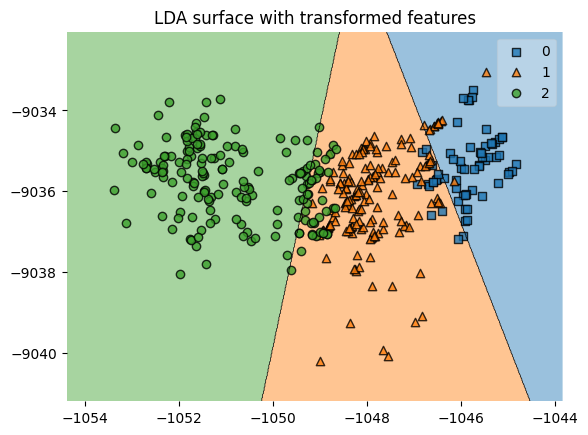

In [50]:
Xs = df[['X5 latitude', 'X6 longitude']]
ys = df['Возраст дома'].values.astype(np.int_)

sk_lda2 = LinearDiscriminantAnalysis(solver='eigen')
X1_lda = sk_lda2.fit(X, ys).transform(X)
print(sk_lda2)
Xs = X1_lda

X1_lda_train, X1_lda_test, y1_train, y1_test = train_test_split(X1_lda, ys, random_state=0)

sk_lda2.fit(X1_lda_train, y1_train)

plt.title('LDA surface with transformed features')
plot_decision_regions(X=X1_lda, y=ys, clf=sk_lda2)

In [51]:
predicted = sk_lda1.predict(X1_lda_test)

In [52]:
from sklearn import model_selection, preprocessing, feature_selection, ensemble, linear_model, metrics, decomposition

## Accuray e AUC
'''
Теперь смотрим метрики.
НА ТЕСТОВОМ ДАТАСЕТЕ
'''
accuracy = metrics.accuracy_score(y1_test, predicted)#Оценим точность классификации.

'''
Получим результат
'''

## Precision e Recall
recall = metrics.recall_score(y1_test, predicted, average="weighted")
precision = metrics.precision_score(y1_test, predicted, average="weighted")
print("Recall (all 1s predicted right):", round(recall,2))
print("Precision (confidence when predicting a 1):", round(precision,2))
print("Detail:")
print(metrics.classification_report(y1_test, predicted, target_names=[str(i) for i in np.unique(y_test)]))

Recall (all 1s predicted right): 0.45
Precision (confidence when predicting a 1): 0.2
Detail:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        15
         1.0       0.00      0.00      0.00        42
         2.0       0.45      1.00      0.62        47

    accuracy                           0.45       104
   macro avg       0.15      0.33      0.21       104
weighted avg       0.20      0.45      0.28       104



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m